In [1]:
!pip install pillow matplotlib opencv-python numpy

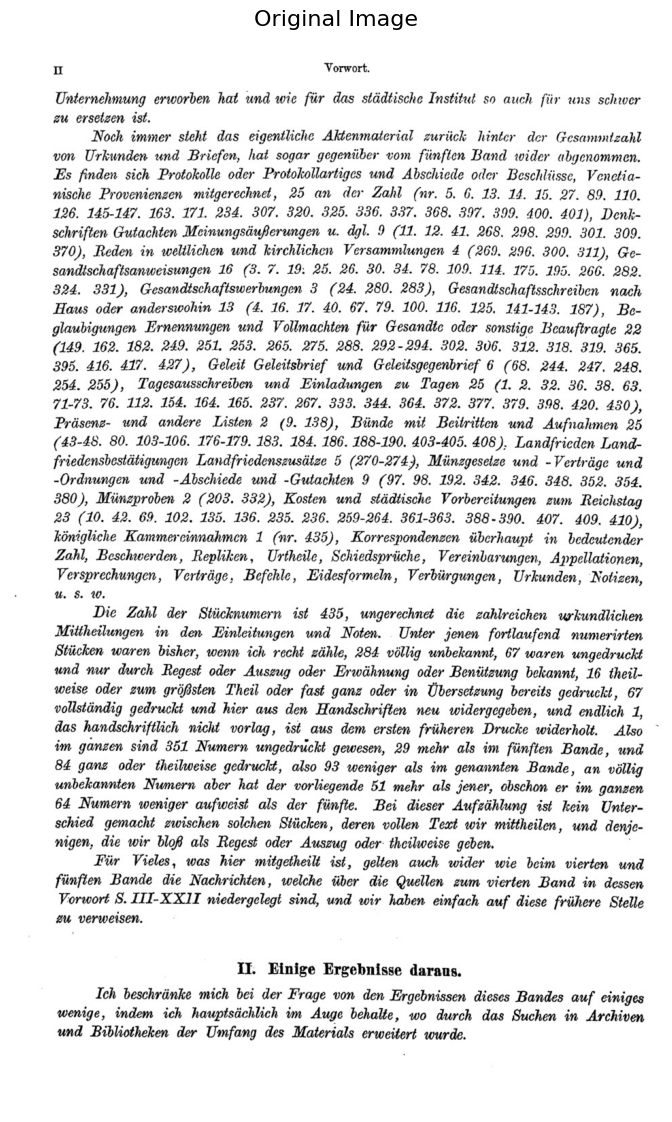

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

#Orginal Image
image_path = "GPT_5.4/images/9.jpg"  


original_img = Image.open(image_path).convert("RGB")


plt.figure(figsize=(10, 14))
plt.imshow(original_img)
plt.title("Original Image", fontsize=16)
plt.axis("off")
plt.show()

In [36]:
import cv2
import numpy as np
from PIL import Image

def preprocess_image_v1(image):
    img = np.array(image.convert("RGB"))


    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    #sharpen 
    kernel = np.array([
        [0, -1, 0],
        [-1, 5,-1],
        [0, -1, 0]
    ])
    sharpened = cv2.filter2D(gray, -1, kernel)


    _, binary = cv2.threshold(
        sharpened,
        180, 
        255,
        cv2.THRESH_BINARY
    )

    return Image.fromarray(binary)

In [37]:
preprocessed_img = preprocess_image_v1(original_img)

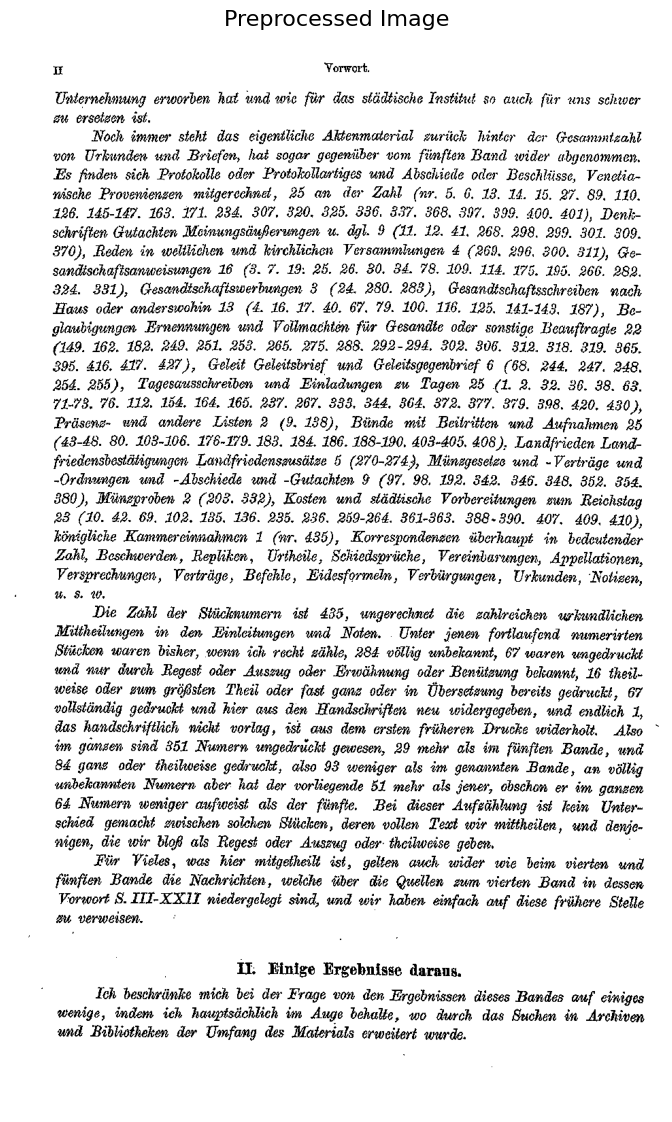

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 14))
plt.imshow(preprocessed_img, cmap="gray")
plt.title("Preprocessed Image", fontsize=16)
plt.axis("off")
plt.show()

In [39]:
output_path = "Preprocessing_test/9_preprocessed_v1.jpg"
preprocessed_img.save(output_path)

print(f"Saved to: {output_path}")

Saved to: Preprocessing_test/9_preprocessed_v1.jpg


In [40]:
import cv2
import numpy as np
from PIL import Image

def preprocess_image_v2(image):
    img = np.array(image.convert("RGB"))


    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)


    contrast = cv2.convertScaleAbs(gray, alpha=1.15, beta=5)


    blur = cv2.GaussianBlur(contrast, (0, 0), 1.0)
    sharpened = cv2.addWeighted(contrast, 1.3, blur, -0.3, 0)

    return Image.fromarray(sharpened)

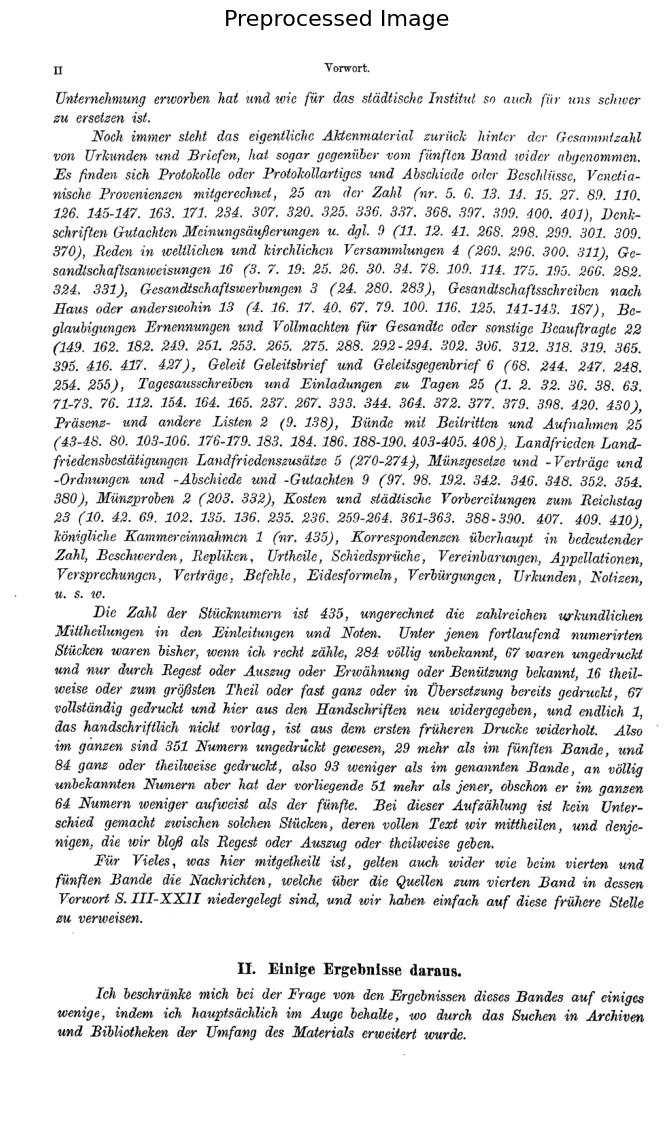

In [41]:
preprocessed_img2 = preprocess_image_v2(original_img)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 14))
plt.imshow(preprocessed_img2, cmap="gray")
plt.title("Preprocessed Image", fontsize=16)
plt.axis("off")
plt.show()

In [42]:
output_path = "Preprocessing_test/9_preprocessed_v2.jpg"
preprocessed_img2.save(output_path)

print(f"Saved to: {output_path}")

Saved to: Preprocessing_test/9_preprocessed_v2.jpg


In [49]:
import cv2
import numpy as np
from PIL import Image

def preprocess_image_v3(image):
    img = np.array(image.convert("RGB"))

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)


    background = cv2.GaussianBlur(gray, (0, 0), 25)
    normalized = cv2.divide(gray, background, scale=255)


    enhanced = cv2.convertScaleAbs(normalized, alpha=1.05, beta=0)


    rgb = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB)

    offwhite = np.array([245, 242, 232], dtype=np.uint8)


    mask = enhanced > 235
    rgb[mask] = offwhite

    return Image.fromarray(rgb)

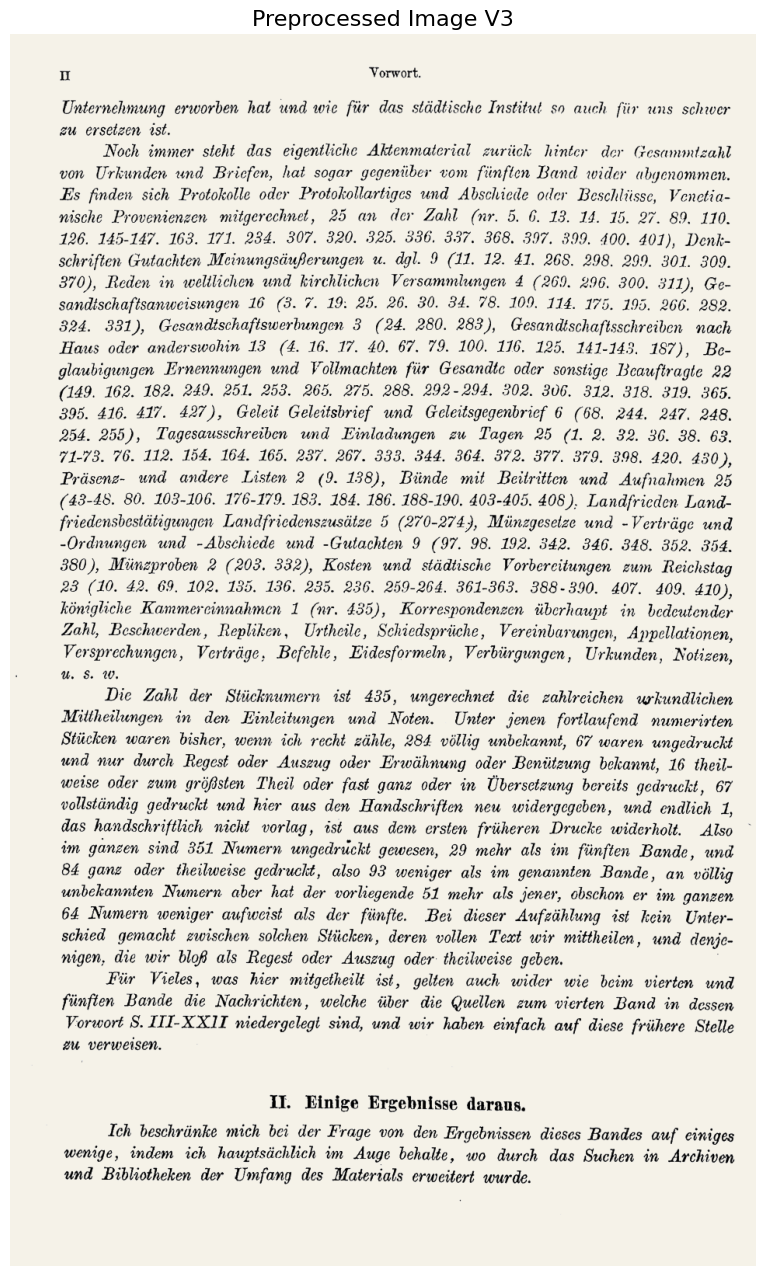

In [50]:
preprocessed_img_v3 = preprocess_image_v3(original_img)

plt.figure(figsize=(10, 16))
plt.imshow(preprocessed_img_v3, cmap="gray")
plt.title("Preprocessed Image V3", fontsize=16)
plt.axis("off")
plt.show()

In [51]:
output_path = "Preprocessing_test/9_preprocessed_v3.jpg"
preprocessed_img_v3.save(output_path)

print(f"Saved to: {output_path}")

Saved to: Preprocessing_test/9_preprocessed_v3.jpg


In [46]:
import cv2
import numpy as np
from PIL import Image

def preprocess_image_v4(image):
    img = np.array(image.convert("RGB"))

    # Grayscale only
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Very mild contrast adjustment
    result = cv2.convertScaleAbs(gray, alpha=1.08, beta=2)

    return Image.fromarray(result)

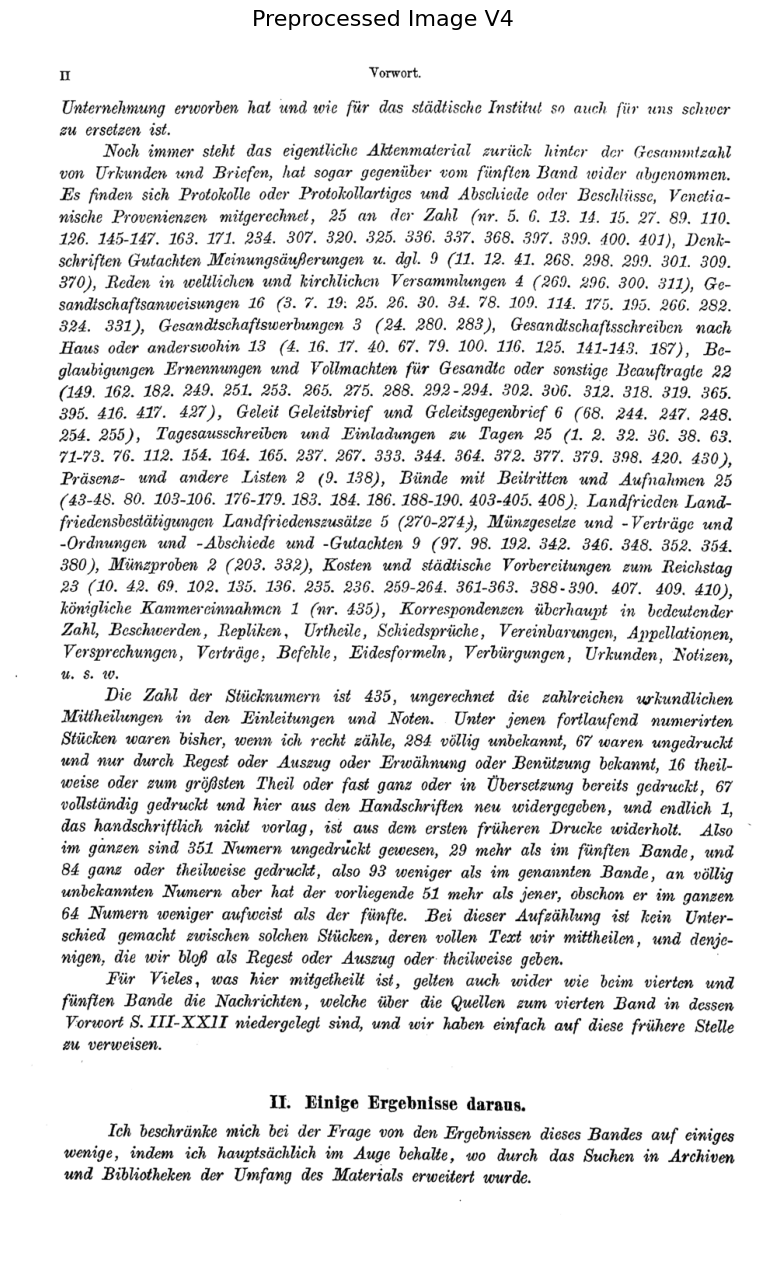

In [47]:
preprocessed_img_v4 = preprocess_image_v4(original_img)

plt.figure(figsize=(10, 16))
plt.imshow(preprocessed_img_v4, cmap="gray")
plt.title("Preprocessed Image V4", fontsize=16)
plt.axis("off")
plt.show()

In [48]:
output_path = "Preprocessing_test/9_preprocessed_v4.jpg"
preprocessed_img_v4.save(output_path)

print(f"Saved to: {output_path}")

Saved to: Preprocessing_test/9_preprocessed_v4.jpg
